<a href="https://colab.research.google.com/github/ranimbouraoui3/LLM-Robustness-Engine-for-Cyber-Physical-Systems/blob/main/Quantify_LLM_Sensitivity_to_Sensor_Perturbation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
stephanmatzka_predictive_maintenance_dataset_ai4i_2020_path = kagglehub.dataset_download('stephanmatzka/predictive-maintenance-dataset-ai4i-2020')

print('Data source import complete.')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import os
from kaggle_secrets import UserSecretsClient


In [ ]:

# --- 1. SETUP & DATA LOADING ---
secret_label = "API_key"
secret_value = UserSecretsClient().get_secret(secret_label)

import kagglehub
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
df = pd.read_csv(os.path.join(path, 'ai4i2020.csv'))

features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


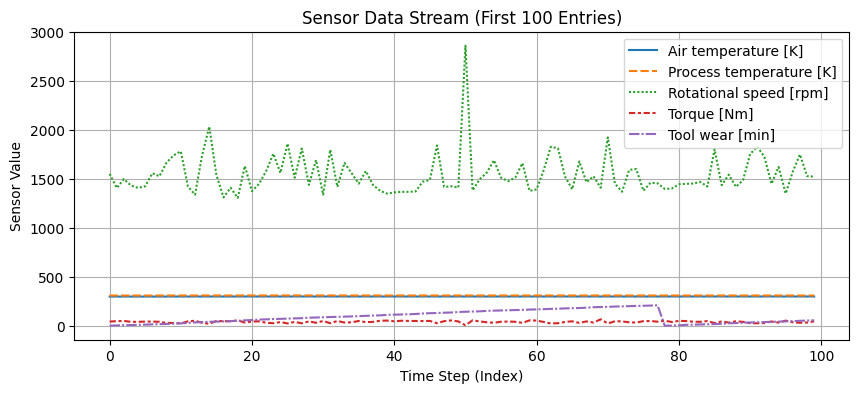

In [ ]:
# --- 1.5 EXPLORATORY DATA ANALYSIS (EDA) ---
# Visualizing a sample of the sensor stream before the experiment
plt.figure(figsize=(10, 4))
sns.lineplot(data=df.iloc[:100][features])
plt.title("Sensor Data Stream (First 100 Entries)")
plt.xlabel("Time Step (Index)")
plt.ylabel("Sensor Value")
plt.grid(True)
plt.show()

# Setup target failure row for the experiment
failure_row = df[df['Machine failure'] == 1].iloc[0][features]


In [ ]:
# --- 2. RESEARCH ENGINE ---
def analyze_with_llm(data_row, label_type="Raw"):
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {secret_value}", "Content-Type": "application/json"}

    # Force strict formatting
    prompt = f"Data: {data_row.astype(float).to_dict()}. Is machine failing? (1=YES, 0=NO). Answer ONLY 'YES' or 'NO'."

    payload = {"model": "llama-3.1-8b-instant", "messages": [{"role": "user", "content": prompt}]}
    response = requests.post(url, headers=headers, json=payload)

    if response.status_code == 200:
        return response.json()['choices'][0]['message']['content'].strip()
    return "ERROR"

In [ ]:
# --- 3. EXPERIMENT: RAW VS FILTERED ---
results = []
noise_levels = [0.0, 0.2, 0.5, 0.8, 1.2]

print("Starting Comparative Robustness Experiment...")
for level in noise_levels:
    noisy_row = failure_row + np.random.normal(0, level * failure_row.std(), failure_row.shape)

    # Test Raw
    pred_raw = analyze_with_llm(noisy_row)

    # Test Filtered (Moving Average)
    filtered_row = pd.Series(noisy_row).rolling(window=2, min_periods=1).mean()
    pred_filtered = analyze_with_llm(filtered_row)

    results.append({'Noise': level, 'Raw': pred_raw, 'Filtered': pred_filtered})
    time.sleep(2.5) # Extended sleep to ensure API stability

results_df = pd.DataFrame(results)

Starting Comparative Robustness Experiment...


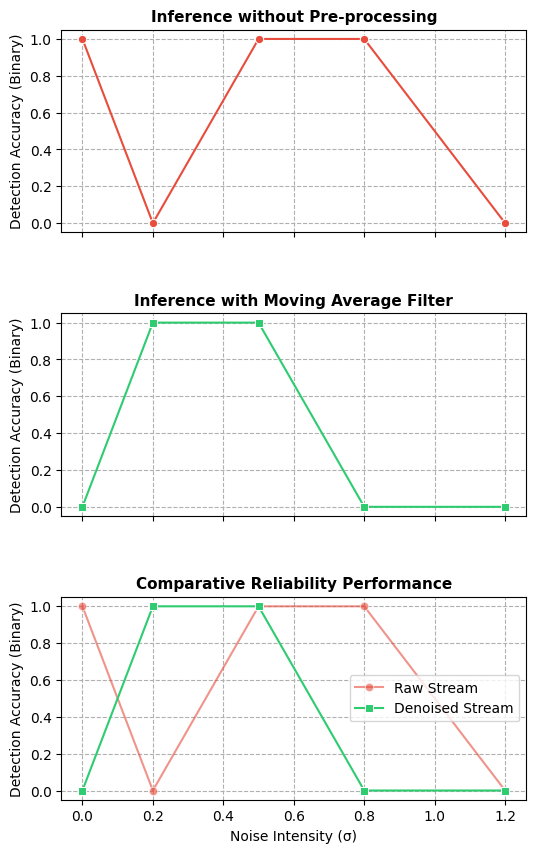


--- PERFORMANCE SUMMARY TABLE ---
   Noise  Raw_Score  Filtered_Score
0    0.0          1               0
1    0.2          0               1
2    0.5          1               1
3    0.8          1               0
4    1.2          0               0


In [ ]:
# --- 4. VISUALIZATION ---
results_df['Raw_Score'] = results_df['Raw'].apply(lambda x: 1 if 'YES' in str(x).upper() else 0)
results_df['Filtered_Score'] = results_df['Filtered'].apply(lambda x: 1 if 'YES' in str(x).upper() else 0)

# Create 3 rows, 1 column with proper spacing
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
plt.subplots_adjust(hspace=0.4) # This adds the needed space between the vertical plots

# Plot 1: Raw LLM
sns.lineplot(ax=axes[0], x='Noise', y='Raw_Score', data=results_df, marker='o', color='#E74C3C', linewidth=1.5)
axes[0].set_title("Inference without Pre-processing", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Detection Accuracy (Binary)")
axes[0].grid(True, linestyle='--')

# Plot 2: Filtered LLM
sns.lineplot(ax=axes[1], x='Noise', y='Filtered_Score', data=results_df, marker='s', color='#2ECC71', linewidth=1.5)
axes[1].set_title("Inference with Moving Average Filter", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Detection Accuracy (Binary)")
axes[1].grid(True, linestyle='--')

# Plot 3: Combined Comparison
sns.lineplot(ax=axes[2], x='Noise', y='Raw_Score', data=results_df, marker='o', color='#E74C3C', label='Raw Stream', alpha=0.6)
sns.lineplot(ax=axes[2], x='Noise', y='Filtered_Score', data=results_df, marker='s', color='#2ECC71', label='Denoised Stream', linewidth=1.5)
axes[2].set_title("Comparative Reliability Performance", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Noise Intensity (σ)")
axes[2].set_ylabel("Detection Accuracy (Binary)")
axes[2].legend()
axes[2].grid(True, linestyle='--')

plt.show()

print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(results_df[['Noise', 'Raw_Score', 'Filtered_Score']])